In [1]:
import time
import pandas as pd
import numpy as np
import multiprocessing as mp
np.random.seed(42)

from econml.dml import CausalForestDML

from causalml.dataset import synthetic_data
from causalml.inference.tree import CausalRandomForestRegressor, CausalTreeRegressor

import matplotlib.pyplot as plt
import seaborn as sns

df_times = pd.DataFrame(columns=['algorithm', 'n', 'time'])

for n in (10000, 30000, 50000):
    Y, X, T, _, _, _ = synthetic_data(mode=2, n=n, p=10, sigma=3.0) # Simulate randomized trial: mode=2

    print(f"--------- n={n} ---------")

    start = time.time()
    ctree = CausalTreeRegressor()
    ctree.fit(X=X, y=Y, treatment=T)

    end = time.time()
    t = round(end - start,1)

    print(f"Tree time: {t}s")
    df_times.loc[-1] = ["Tree", n ,t ]  # adding a row
    df_times.index = df_times.index + 1 
    
    start = time.time()
    # crforest = CausalRandomForestRegressor(criterion="causal_mse",
    #                               min_samples_leaf=200,
    #                               control_name=0,
    #                               n_estimators=50,
    #                               n_jobs=mp.cpu_count() - 1)
    # crforest.fit(X=X_train, y=y_train, treatment=treatment_train)
    est = CausalForestDML(n_estimators=60, discrete_treatment=True)
    est.fit(Y=Y, T=T, X=X, inference="blb")
    end = time.time()
    
    t = round(end - start,1)
    print(f"Forest time: {t}s")
    df_times.loc[-1] = ["Forest", n ,t ]  # adding a row
    df_times.index = df_times.index + 1 


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
Failed to import duecredit due to No module named 'duecredit'


--------- n=10000 ---------
Tree time: 0.1s
Forest time: 35.9s
--------- n=30000 ---------
Tree time: 0.8s
Forest time: 139.0s
--------- n=50000 ---------
Tree time: 1.1s
Forest time: 317.2s


TypeError: Data source must be a DataFrame or Mapping, not <class 'pandas.core.series.Series'>.

In [2]:
df_times

,algorithm,n,time
5,Tree,10000,0.1
4,Forest,10000,35.9
3,Tree,30000,0.8
2,Forest,30000,139.0
1,Tree,50000,1.1
0,Forest,50000,317.2


In [3]:
df_times['time'] = df_times['time']/60

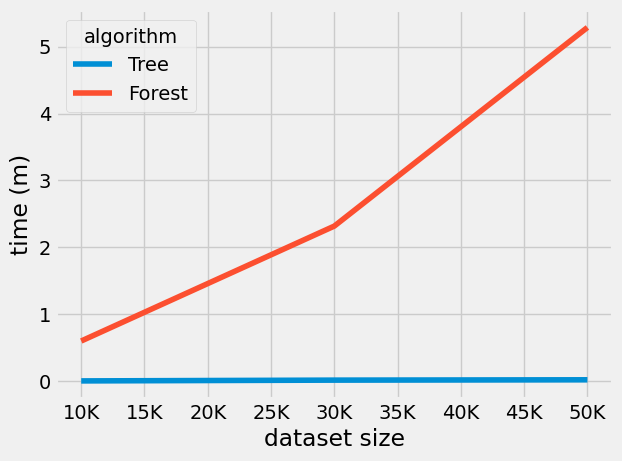

In [5]:
x = list(df_times['n'].unique())
# plot the time taken for each algorithm using a line plot
g = sns.lineplot(data=df_times, x='n', y='time', hue='algorithm')
plt.ylabel('time (m)')
plt.xlabel('dataset size')

# g.set(xlim = (0,1000000))
xlabels = ['{:,.0f}'.format(x) + 'K' for x in g.get_xticks()/1000]
g.set_xticklabels(xlabels)
plt.show()